# Executive Dashboard - Enhanced
## Comprehensive Platform Analytics & Business Intelligence
**Date:** 2026-02-01 | **Version:** Enhanced v2.0

This enhanced dashboard provides deep insights into platform performance with advanced visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Enhanced styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('[OK] Enhanced libraries loaded with advanced styling')

[OK] Enhanced libraries loaded with advanced styling


## 1. Load & Explore Data

In [2]:
# Load all datasets
users_df = pd.read_csv('../mock_data/users.csv', encoding='utf-8-sig')
brands_df = pd.read_csv('../mock_data/brands.csv', encoding='utf-8-sig')
products_df = pd.read_csv('../mock_data/products.csv', encoding='utf-8-sig')
orders_df = pd.read_csv('../mock_data/orders.csv', encoding='utf-8-sig')
payments_df = pd.read_csv('../mock_data/payments.csv', encoding='utf-8-sig')
reviews_df = pd.read_csv('../mock_data/reviews.csv', encoding='utf-8-sig')

# Parse dates
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
users_df['created_at'] = pd.to_datetime(users_df['created_at'])

print('[DATA] Loaded successfully!')
print(f'  Users: {len(users_df):,}')
print(f'  Brands: {len(brands_df):,}')
print(f'  Products: {len(products_df):,}')
print(f'  Orders: {len(orders_df):,}')
print(f'  Payments: {len(payments_df):,}')
print(f'  Reviews: {len(reviews_df):,}')

# Quick stats
print(f'\n[STATS] Data Quality:')
print(f'  Date Range: {orders_df["order_date"].min().date()} to {orders_df["order_date"].max().date()}')
print(f'  Order Statuses: {orders_df["status"].nunique()} unique')
print(f'  Categories: {products_df["category"].nunique()} unique')

[DATA] Loaded successfully!
  Users: 600
  Brands: 100
  Products: 500
  Orders: 2,000
  Payments: 2,000
  Reviews: 400

[STATS] Data Quality:
  Date Range: 2024-06-03 to 2026-01-26
  Order Statuses: 4 unique
  Categories: 3 unique


## 2. Executive KPI Dashboard

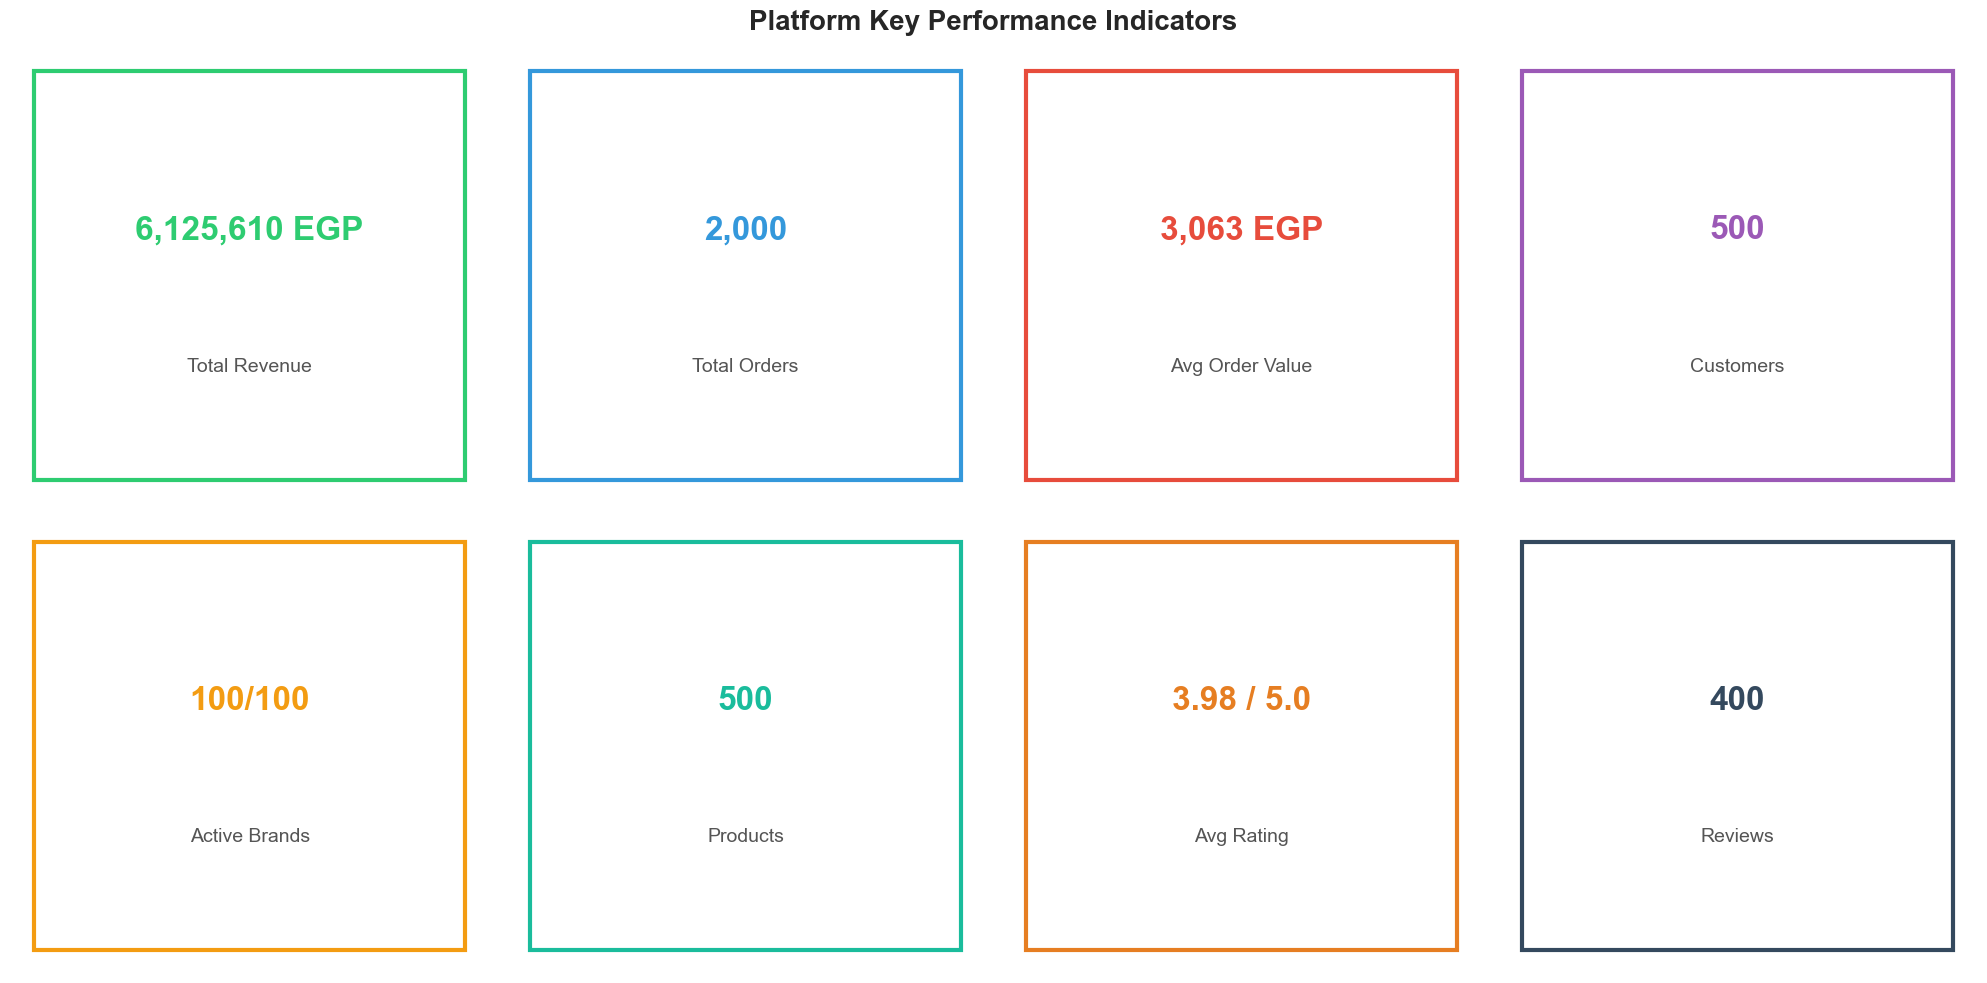

EXECUTIVE KPI SUMMARY
Total Revenue................. 6,125,610 EGP
Total Orders.................. 2,000
Avg Order Value............... 3,063 EGP
Customers..................... 500
Active Brands................. 100/100
Products...................... 500
Avg Rating.................... 3.98 / 5.0
Reviews....................... 400


In [3]:
# Calculate comprehensive KPIs
total_revenue = orders_df['total_price_egp'].sum()
total_orders = len(orders_df)
avg_order_value = orders_df['total_price_egp'].mean()
total_customers = len(users_df[users_df['user_type'] == 'customer'])
total_owners = len(users_df[users_df['user_type'] == 'owner'])
active_brands = len(brands_df[brands_df['total_orders'] > 0])
avg_rating = reviews_df['rating'].mean()
total_products = len(products_df)

# Display KPI Grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Platform Key Performance Indicators', fontsize=20, fontweight='bold', y=0.98)

kpis = [
    ('Total Revenue', f'{total_revenue:,.0f} EGP', '#2ECC71'),
    ('Total Orders', f'{total_orders:,}', '#3498DB'),
    ('Avg Order Value', f'{avg_order_value:,.0f} EGP', '#E74C3C'),
    ('Customers', f'{total_customers:,}', '#9B59B6'),
    ('Active Brands', f'{active_brands}/{total_owners}', '#F39C12'),
    ('Products', f'{total_products:,}', '#1ABC9C'),
    ('Avg Rating', f'{avg_rating:.2f} / 5.0', '#E67E22'),
    ('Reviews', f'{len(reviews_df):,}', '#34495E')
]

for idx, (ax, (title, value, color)) in enumerate(zip(axes.flat, kpis)):
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=24, fontweight='bold', color=color)
    ax.text(0.5, 0.3, title, ha='center', va='center', fontsize=14, color='#555')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=color, linewidth=3))

plt.tight_layout()
plt.show()

print('='*70)
print('EXECUTIVE KPI SUMMARY')
print('='*70)
for title, value, _ in kpis:
    print(f'{title:.<30} {value}')
print('='*70)

## 3. Revenue Analysis - Multi-Dimensional

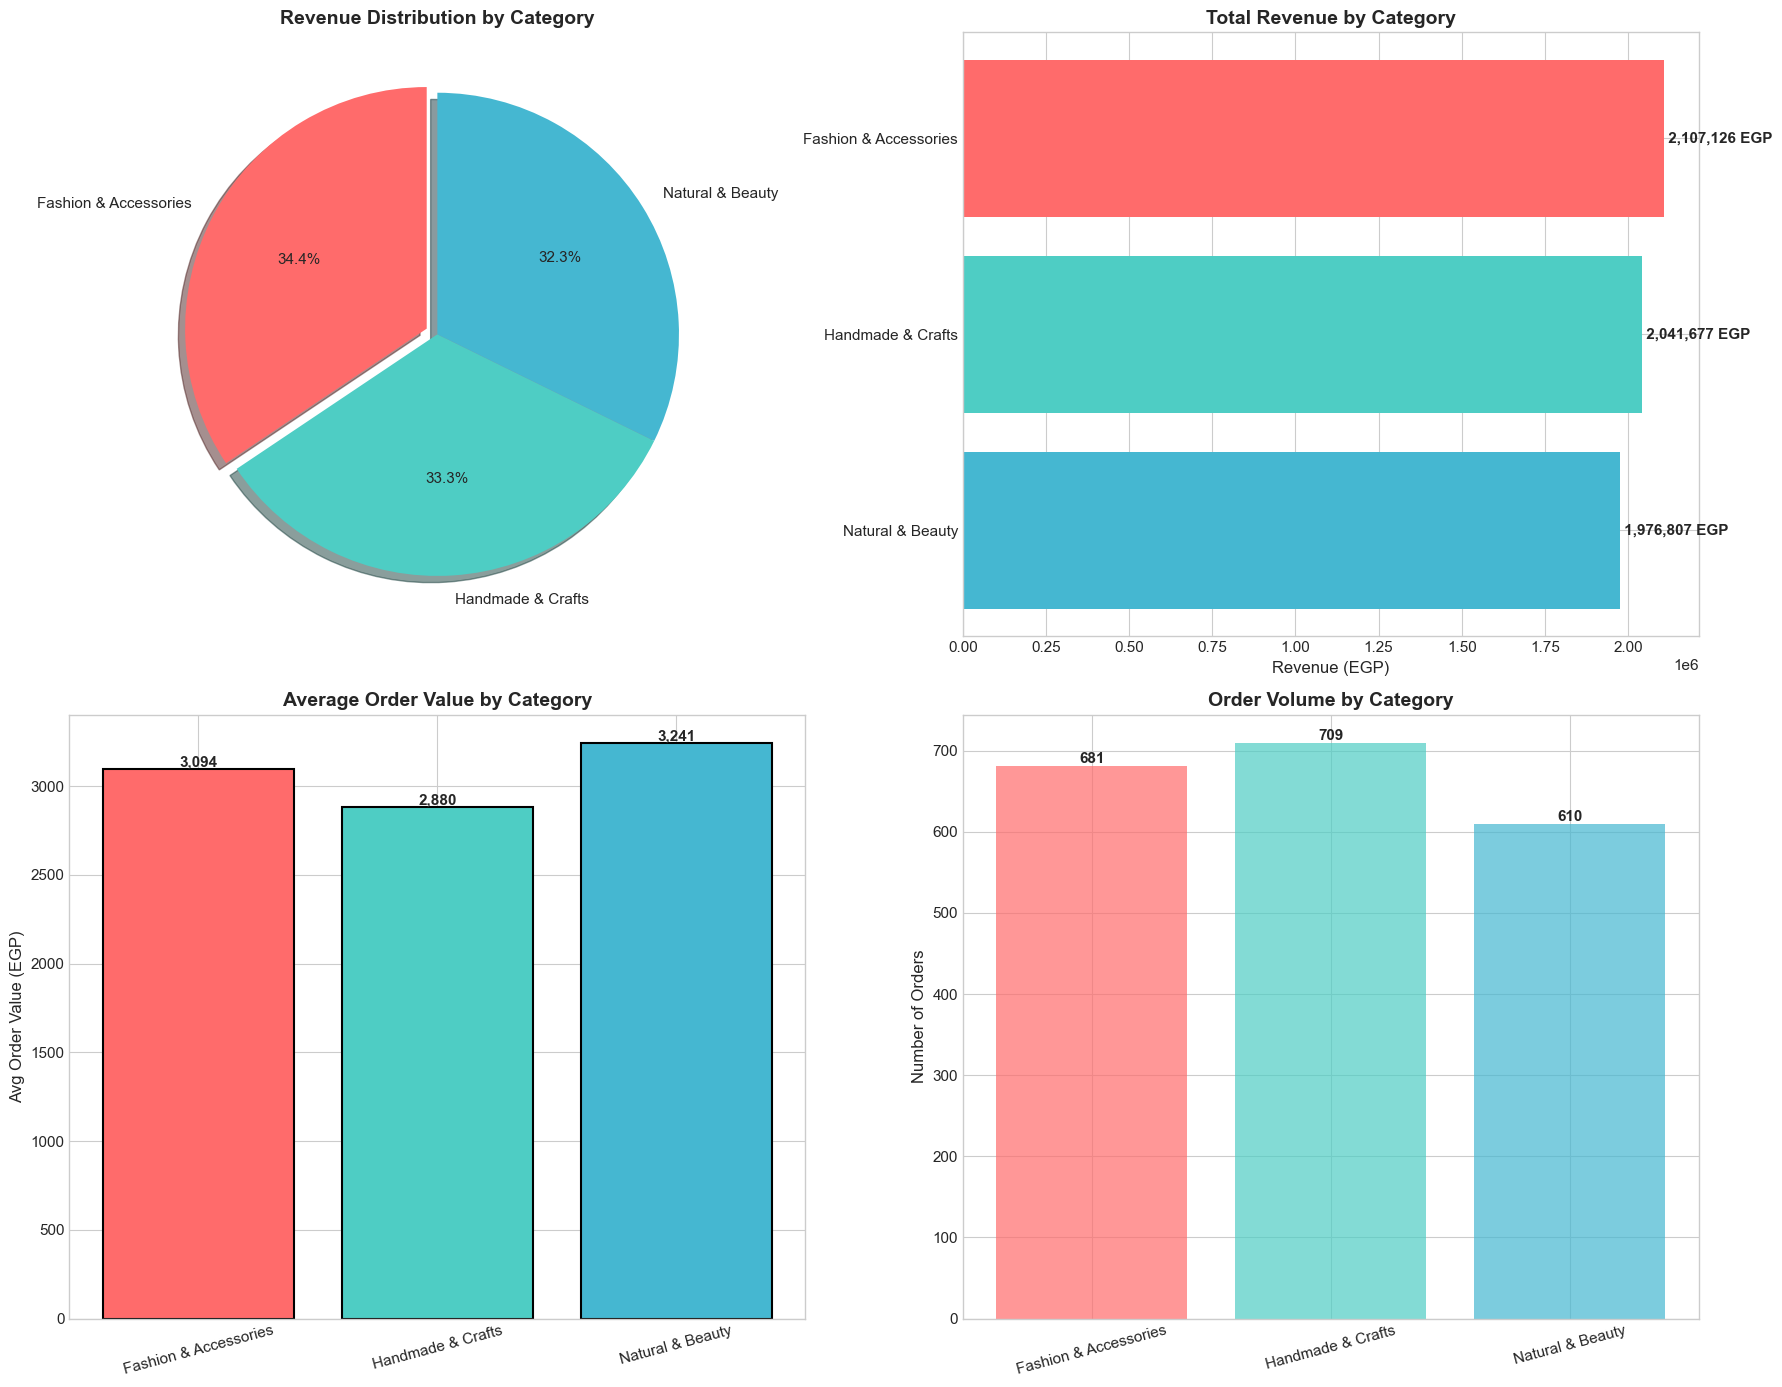


[REVENUE] Category Breakdown:
  Fashion & Accessories......... 2,107,125.59 EGP  ( 681 orders)
  Handmade & Crafts............. 2,041,677.22 EGP  ( 709 orders)
  Natural & Beauty.............. 1,976,807.08 EGP  ( 610 orders)


In [4]:
# Revenue by category
orders_with_cat = orders_df.merge(products_df[['product_id', 'category']], on='product_id', how='left')
cat_revenue = orders_with_cat.groupby('category')['total_price_egp'].agg(['sum', 'mean', 'count']).reset_index()
cat_revenue.columns = ['category', 'total_revenue', 'avg_order', 'order_count']
cat_revenue = cat_revenue.sort_values('total_revenue', ascending=False)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 1. Revenue Pie Chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
explode = [0.05 if i == 0 else 0 for i in range(len(cat_revenue))]
ax1.pie(cat_revenue['total_revenue'], labels=cat_revenue['category'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=explode, shadow=True)
ax1.set_title('Revenue Distribution by Category', fontweight='bold', fontsize=14)

# 2. Revenue Bar Chart with values
bars = ax2.barh(cat_revenue['category'], cat_revenue['total_revenue'], color=colors)
ax2.set_title('Total Revenue by Category', fontweight='bold', fontsize=14)
ax2.set_xlabel('Revenue (EGP)', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, cat_revenue['total_revenue'])):
    ax2.text(val, i, f' {val:,.0f} EGP', va='center', fontweight='bold')
ax2.invert_yaxis()

# 3. Average Order Value by Category
bars3 = ax3.bar(cat_revenue['category'], cat_revenue['avg_order'], color=colors, edgecolor='black', linewidth=1.5)
ax3.set_title('Average Order Value by Category', fontweight='bold', fontsize=14)
ax3.set_ylabel('Avg Order Value (EGP)', fontsize=12)
ax3.tick_params(axis='x', rotation=15)
for bar, val in zip(bars3, cat_revenue['avg_order']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Order Count by Category
bars4 = ax4.bar(cat_revenue['category'], cat_revenue['order_count'], color=colors, alpha=0.7)
ax4.set_title('Order Volume by Category', fontweight='bold', fontsize=14)
ax4.set_ylabel('Number of Orders', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
for bar, val in zip(bars4, cat_revenue['order_count']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n[REVENUE] Category Breakdown:')
for _, row in cat_revenue.iterrows():
    print(f'  {row["category"]:.<30} {row["total_revenue"]:>12,.2f} EGP  ({row["order_count"]:>4} orders)')

## 4. Time Series Analysis

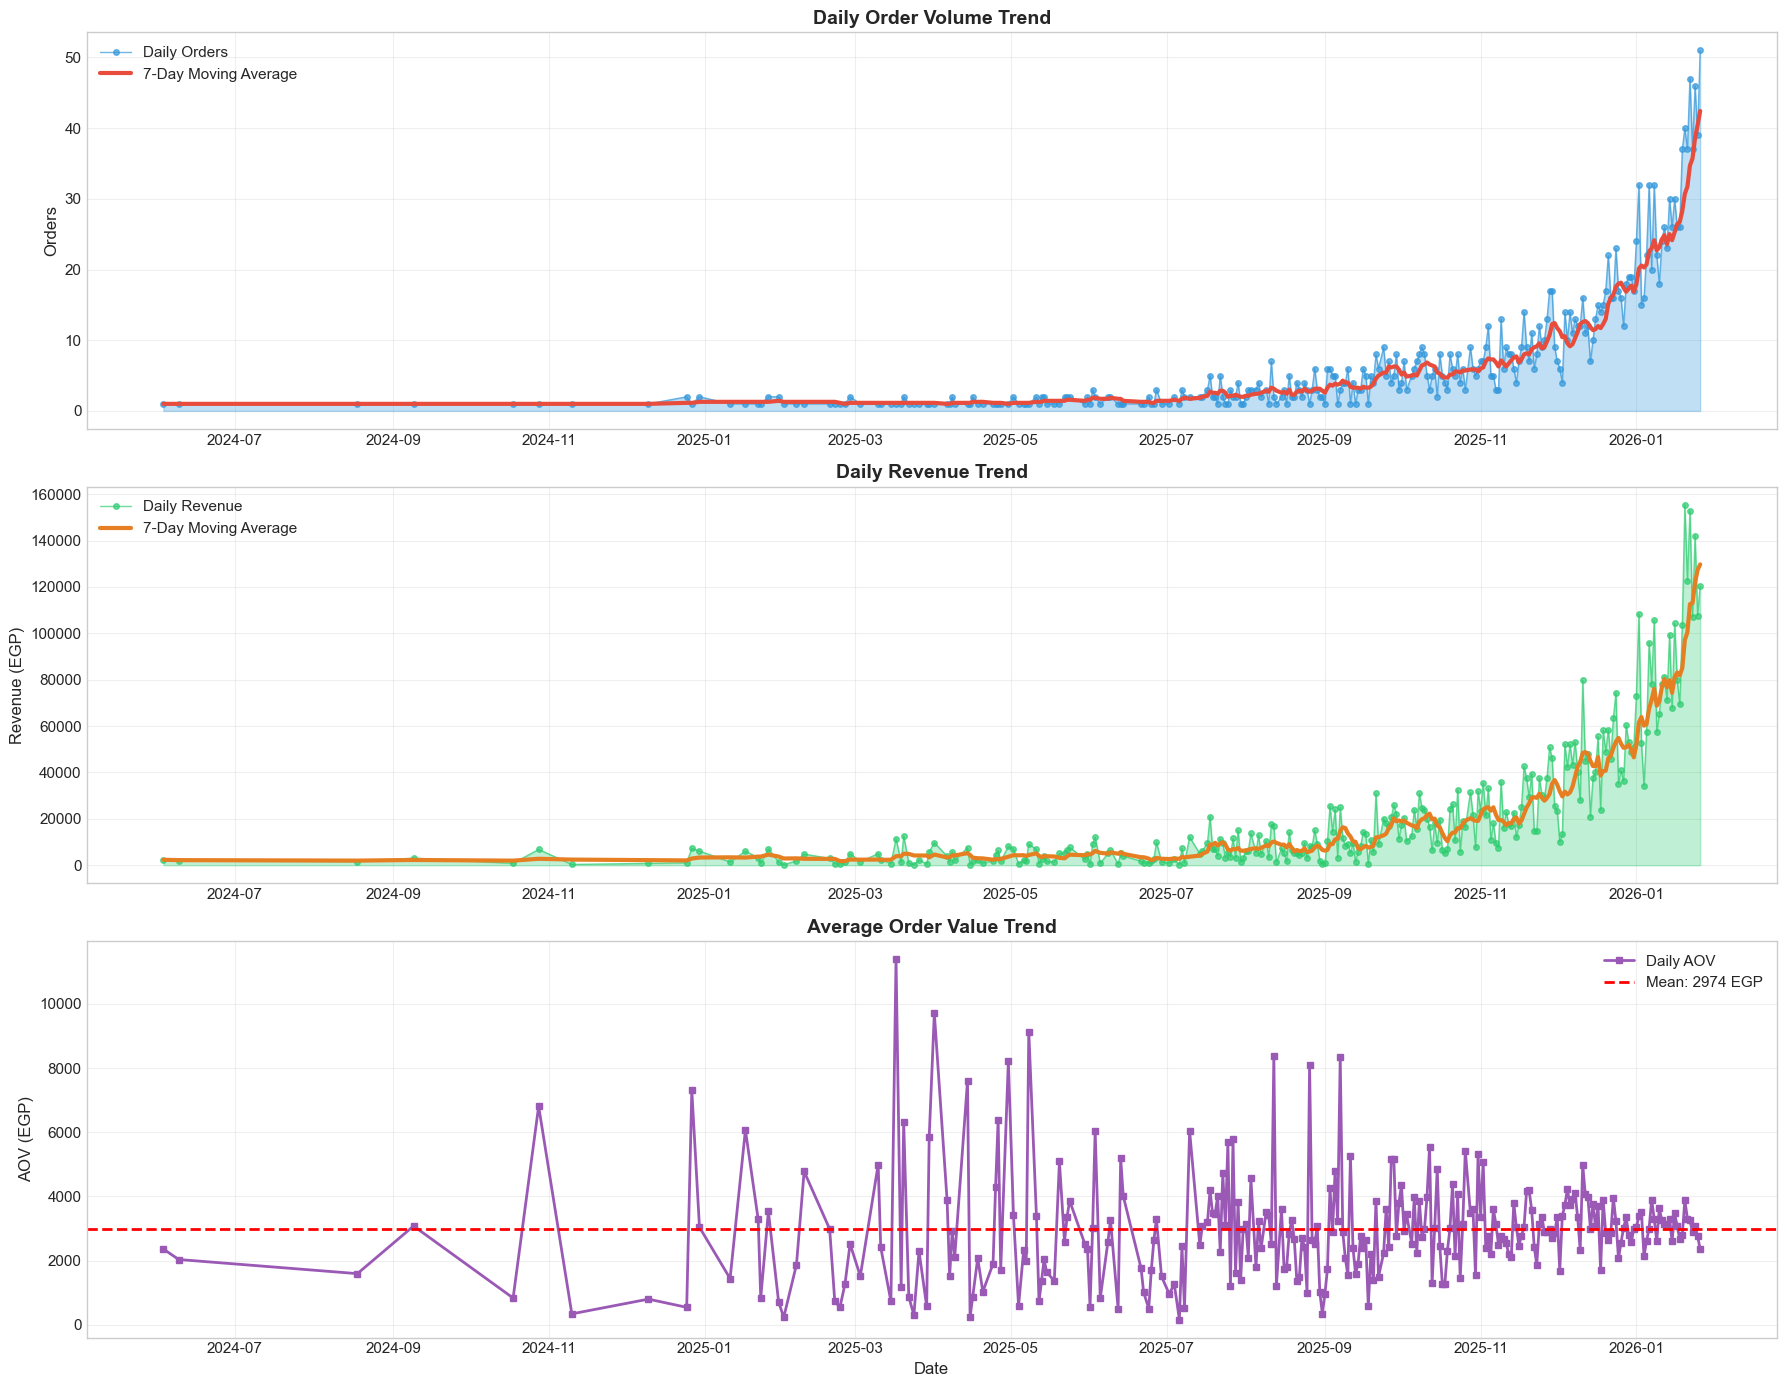


[TRENDS] Summary:
  Peak Orders Day: 2026-01-26 (51 orders)
  Peak Revenue Day: 2026-01-20 (155,461 EGP)
  Highest AOV Day: 2025-03-17 (11,400 EGP)


In [5]:
# Daily aggregations
daily_stats = orders_df.groupby(orders_df['order_date'].dt.date).agg({
    'order_id': 'count',
    'total_price_egp': ['sum', 'mean']
}).reset_index()
daily_stats.columns = ['date', 'orders', 'revenue', 'avg_order_value']
daily_stats['date'] = pd.to_datetime(daily_stats['date'])
daily_stats['revenue_ma7'] = daily_stats['revenue'].rolling(window=7, min_periods=1).mean()
daily_stats['orders_ma7'] = daily_stats['orders'].rolling(window=7, min_periods=1).mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 14))

# Orders over time
ax1.fill_between(daily_stats['date'], daily_stats['orders'], alpha=0.3, color='#3498DB')
ax1.plot(daily_stats['date'], daily_stats['orders'], marker='o', markersize=4,
         linewidth=1, alpha=0.7, color='#3498DB', label='Daily Orders')
ax1.plot(daily_stats['date'], daily_stats['orders_ma7'], linewidth=3,
         color='#E74C3C', label='7-Day Moving Average')
ax1.set_title('Daily Order Volume Trend', fontweight='bold', fontsize=14)
ax1.set_ylabel('Orders', fontsize=12)
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)

# Revenue over time
ax2.fill_between(daily_stats['date'], daily_stats['revenue'], alpha=0.3, color='#2ECC71')
ax2.plot(daily_stats['date'], daily_stats['revenue'], marker='o', markersize=4,
         linewidth=1, alpha=0.7, color='#2ECC71', label='Daily Revenue')
ax2.plot(daily_stats['date'], daily_stats['revenue_ma7'], linewidth=3,
         color='#E67E22', label='7-Day Moving Average')
ax2.set_title('Daily Revenue Trend', fontweight='bold', fontsize=14)
ax2.set_ylabel('Revenue (EGP)', fontsize=12)
ax2.legend(loc='best', fontsize=11)
ax2.grid(True, alpha=0.3)

# Average Order Value over time
ax3.plot(daily_stats['date'], daily_stats['avg_order_value'], marker='s', markersize=5,
         linewidth=2, color='#9B59B6', label='Daily AOV')
ax3.axhline(daily_stats['avg_order_value'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {daily_stats["avg_order_value"].mean():.0f} EGP')
ax3.set_title('Average Order Value Trend', fontweight='bold', fontsize=14)
ax3.set_ylabel('AOV (EGP)', fontsize=12)
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='best', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n[TRENDS] Summary:')
print(f'  Peak Orders Day: {daily_stats.loc[daily_stats["orders"].idxmax(), "date"].strftime("%Y-%m-%d")} ({daily_stats["orders"].max()} orders)')
print(f'  Peak Revenue Day: {daily_stats.loc[daily_stats["revenue"].idxmax(), "date"].strftime("%Y-%m-%d")} ({daily_stats["revenue"].max():,.0f} EGP)')
print(f'  Highest AOV Day: {daily_stats.loc[daily_stats["avg_order_value"].idxmax(), "date"].strftime("%Y-%m-%d")} ({daily_stats["avg_order_value"].max():,.0f} EGP)')

## 5. Geographic Heatmap & Distribution

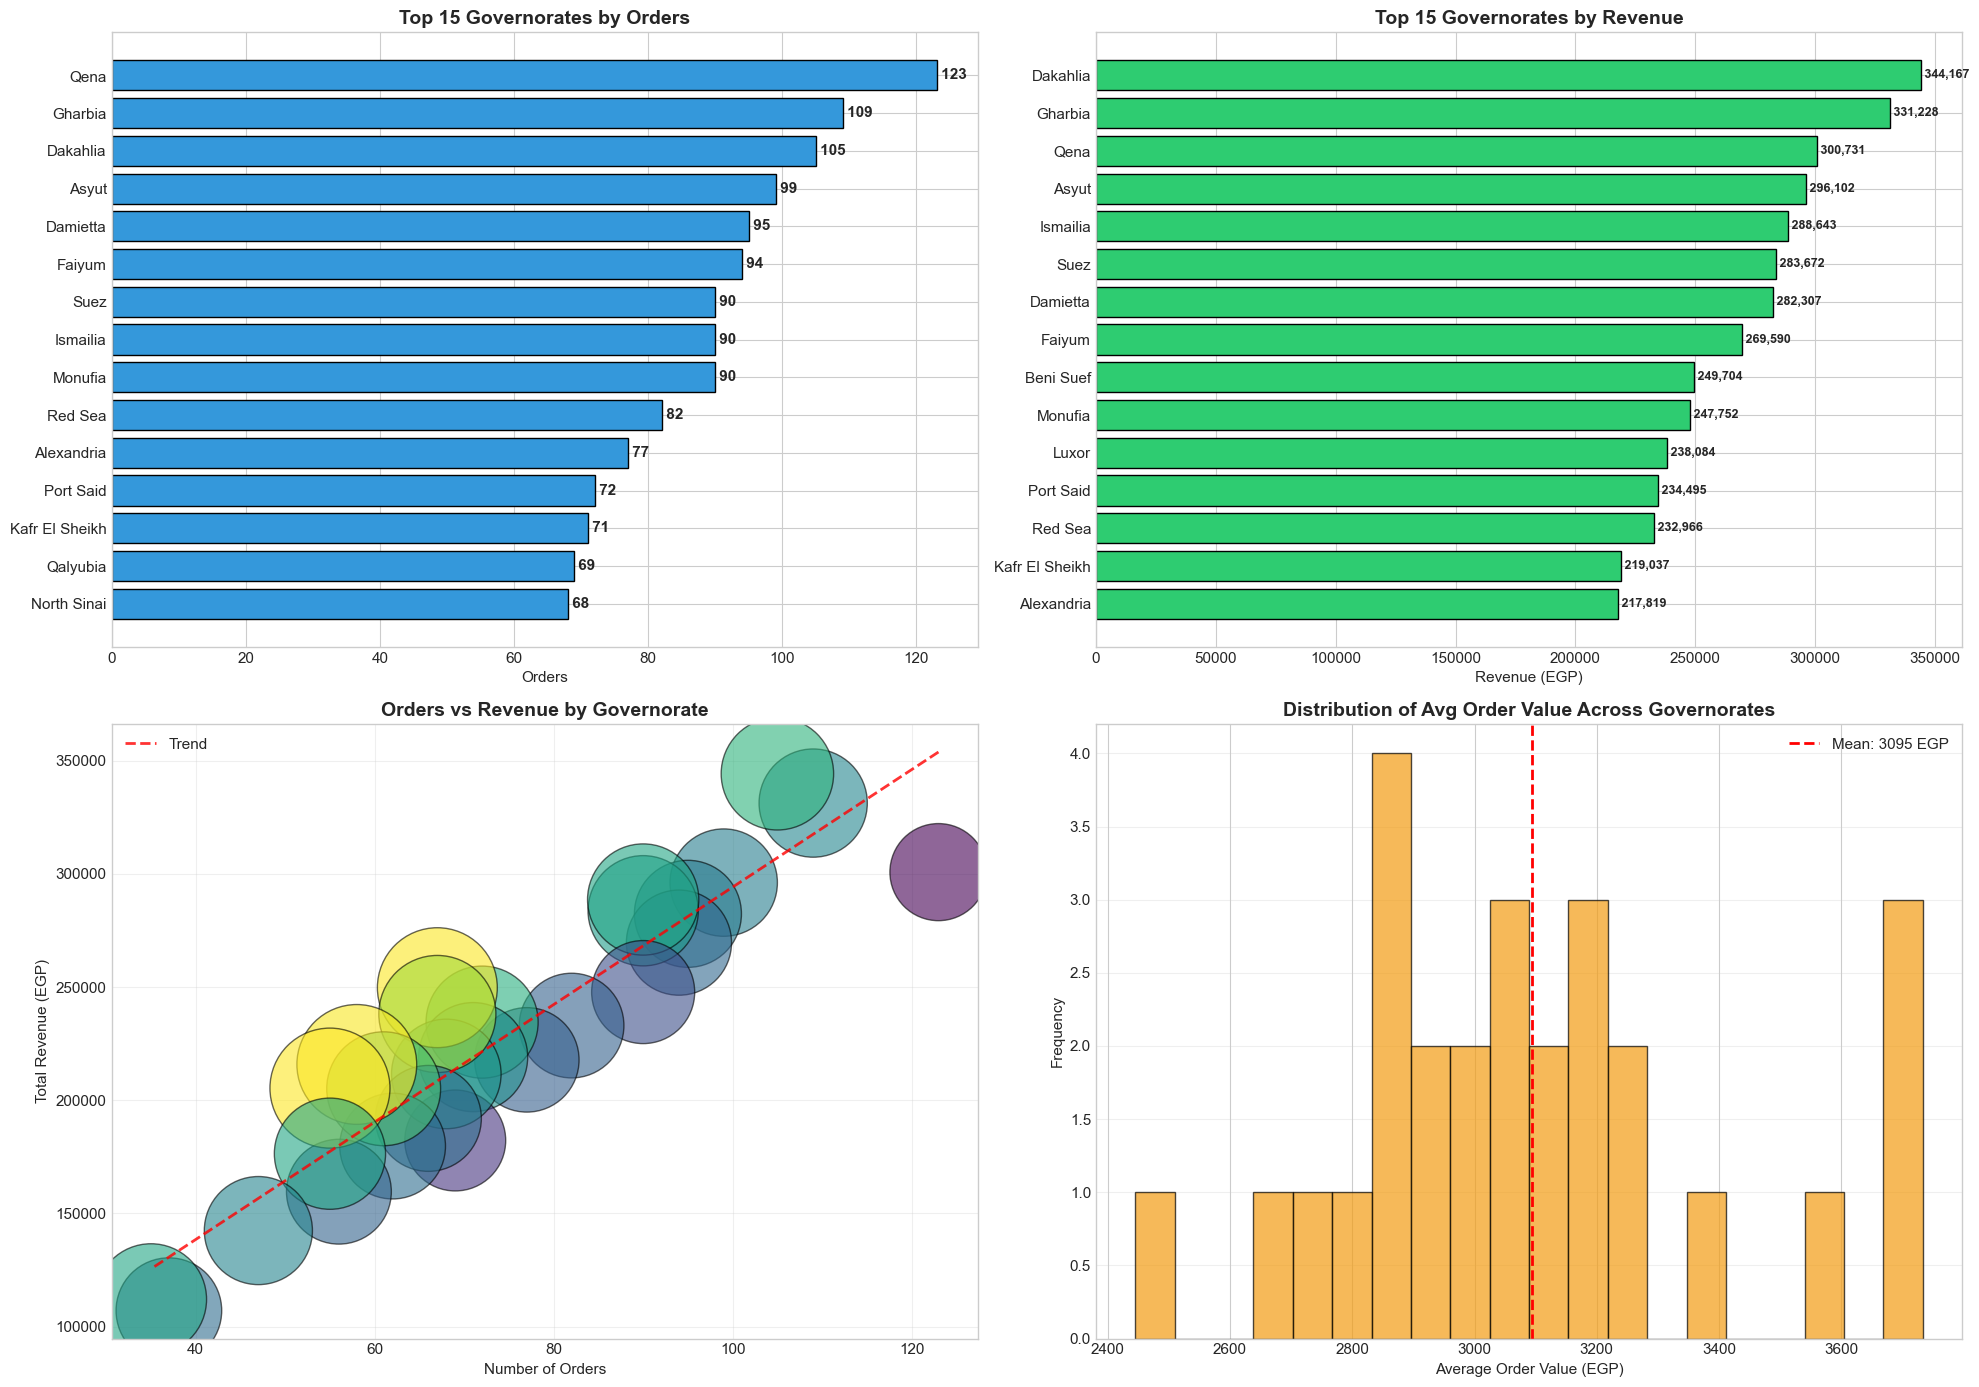

In [6]:
# Geographic analysis
gov_stats = orders_df.groupby('shipping_governorate').agg({
    'order_id': 'count',
    'total_price_egp': ['sum', 'mean']
}).reset_index()
gov_stats.columns = ['governorate', 'orders', 'revenue', 'avg_order']
gov_stats = gov_stats.sort_values('orders', ascending=False)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 14))

# Top 15 by orders
top15_orders = gov_stats.head(15)
bars1 = ax1.barh(range(len(top15_orders)), top15_orders['orders'], color='#3498DB', edgecolor='black')
ax1.set_yticks(range(len(top15_orders)))
ax1.set_yticklabels(top15_orders['governorate'])
ax1.set_title('Top 15 Governorates by Orders', fontweight='bold', fontsize=14)
ax1.set_xlabel('Orders')
ax1.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars1, top15_orders['orders'])):
    ax1.text(val, i, f' {int(val)}', va='center', fontweight='bold')

# Top 15 by revenue
top15_revenue = gov_stats.sort_values('revenue', ascending=False).head(15)
bars2 = ax2.barh(range(len(top15_revenue)), top15_revenue['revenue'], color='#2ECC71', edgecolor='black')
ax2.set_yticks(range(len(top15_revenue)))
ax2.set_yticklabels(top15_revenue['governorate'])
ax2.set_title('Top 15 Governorates by Revenue', fontweight='bold', fontsize=14)
ax2.set_xlabel('Revenue (EGP)')
ax2.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars2, top15_revenue['revenue'])):
    ax2.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=9)

# Scatter: Orders vs Revenue
ax3.scatter(gov_stats['orders'], gov_stats['revenue'], s=gov_stats['avg_order']*2,
            alpha=0.6, c=gov_stats['avg_order'], cmap='viridis', edgecolors='black', linewidth=1)
ax3.set_title('Orders vs Revenue by Governorate', fontweight='bold', fontsize=14)
ax3.set_xlabel('Number of Orders')
ax3.set_ylabel('Total Revenue (EGP)')
ax3.grid(True, alpha=0.3)
# Add trendline
z = np.polyfit(gov_stats['orders'], gov_stats['revenue'], 1)
p = np.poly1d(z)
ax3.plot(gov_stats['orders'], p(gov_stats['orders']), 
         "r--", alpha=0.8, linewidth=2, label='Trend')
ax3.legend()

# Distribution of Average Order Values
ax4.hist(gov_stats['avg_order'], bins=20, color='#F39C12', edgecolor='black', alpha=0.7)
ax4.axvline(gov_stats['avg_order'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {gov_stats["avg_order"].mean():.0f} EGP')
ax4.set_title('Distribution of Avg Order Value Across Governorates', fontweight='bold', fontsize=14)
ax4.set_xlabel('Average Order Value (EGP)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Advanced Statistics & Insights

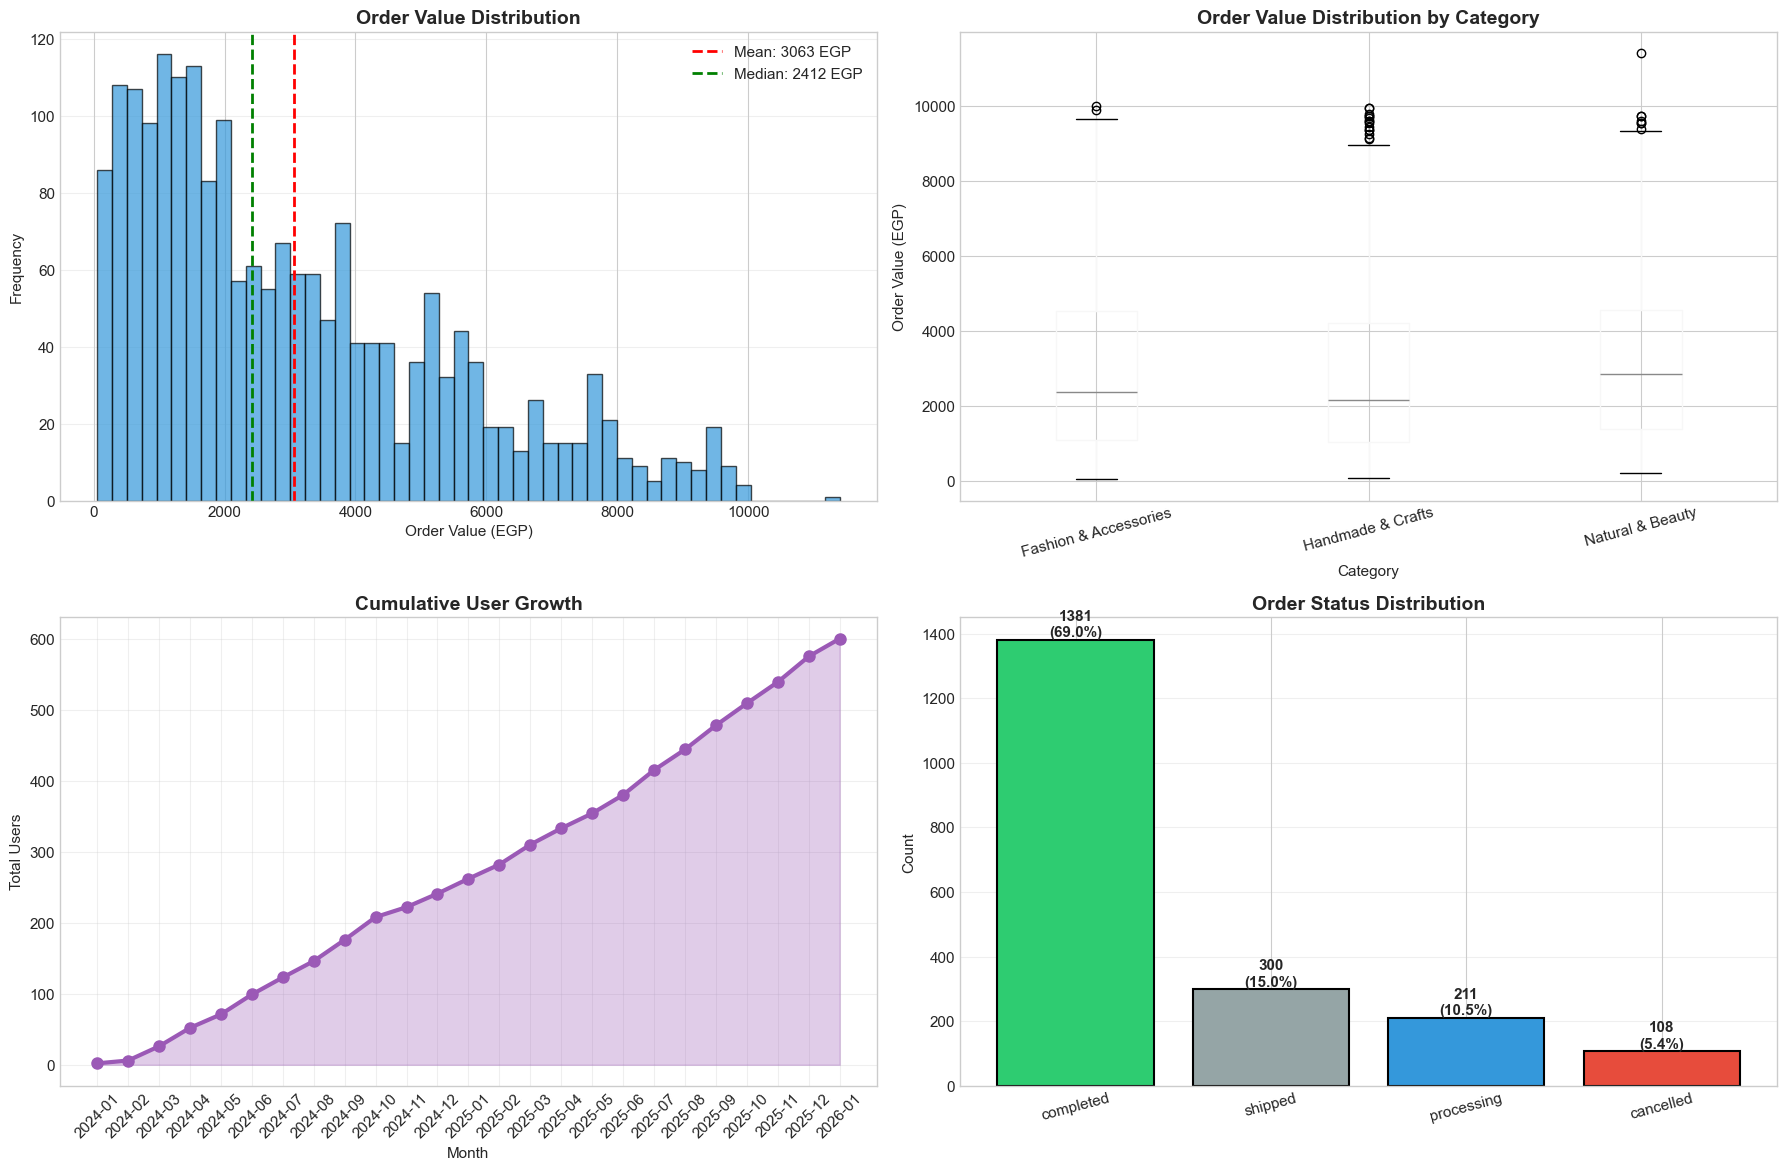


[STATISTICS] Order Value Metrics:
  Mean: 3062.80 EGP
  Median: 2412.16 EGP
  Std Dev: 2387.32 EGP
  Min: 53.08 EGP
  Max: 11399.70 EGP


In [7]:
# Statistical summary
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# 1. Order Value Distribution
ax1.hist(orders_df['total_price_egp'], bins=50, color='#3498DB', edgecolor='black', alpha=0.7)
ax1.axvline(orders_df['total_price_egp'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {orders_df["total_price_egp"].mean():.0f} EGP')
ax1.axvline(orders_df['total_price_egp'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: {orders_df["total_price_egp"].median():.0f} EGP')
ax1.set_title('Order Value Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Order Value (EGP)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Box plot by category
orders_with_cat.boxplot(column='total_price_egp', by='category', ax=ax2)
ax2.set_title('Order Value Distribution by Category', fontweight='bold', fontsize=14)
ax2.set_ylabel('Order Value (EGP)')
ax2.set_xlabel('Category')
plt.sca(ax2)
plt.xticks(rotation=15)
ax2.get_figure().suptitle('')  # Remove default title

# 3. User Growth Over Time
user_growth = users_df.groupby(users_df['created_at'].dt.to_period('M')).size().cumsum()
ax3.plot(user_growth.index.astype(str), user_growth.values, marker='o',
         linewidth=3, markersize=8, color='#9B59B6')
ax3.fill_between(range(len(user_growth)), user_growth.values, alpha=0.3, color='#9B59B6')
ax3.set_title('Cumulative User Growth', fontweight='bold', fontsize=14)
ax3.set_ylabel('Total Users')
ax3.set_xlabel('Month')
ax3.grid(True, alpha=0.3)
plt.sca(ax3)
plt.xticks(rotation=45)

# 4. Order Status Distribution
status_counts = orders_df['status'].value_counts()
colors_status = {'completed': '#2ECC71', 'pending': '#F39C12', 
                 'cancelled': '#E74C3C', 'processing': '#3498DB'}
bar_colors = [colors_status.get(s, '#95A5A6') for s in status_counts.index]
bars4 = ax4.bar(status_counts.index, status_counts.values, color=bar_colors, edgecolor='black', linewidth=1.5)
ax4.set_title('Order Status Distribution', fontweight='bold', fontsize=14)
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=15)
for bar, val in zip(bars4, status_counts.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val)}\n({val/len(orders_df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n[STATISTICS] Order Value Metrics:')
print(f'  Mean: {orders_df["total_price_egp"].mean():.2f} EGP')
print(f'  Median: {orders_df["total_price_egp"].median():.2f} EGP')
print(f'  Std Dev: {orders_df["total_price_egp"].std():.2f} EGP')
print(f'  Min: {orders_df["total_price_egp"].min():.2f} EGP')
print(f'  Max: {orders_df["total_price_egp"].max():.2f} EGP')

## 7. Executive Summary & AI Recommendations

In [8]:
print('\n' + '='*80)
print('EXECUTIVE SUMMARY & AI-POWERED RECOMMENDATIONS')
print('='*80)

print('\n[KEY FINDINGS]')
print(f'  1. Platform generated {total_revenue:,.0f} EGP from {total_orders} orders')
print(f'  2. Average order value is {avg_order_value:,.0f} EGP')
print(f'  3. {active_brands}/{total_owners} brands are actively selling ({active_brands/total_owners*100:.1f}%)')
print(f'  4. Customer satisfaction: {avg_rating:.2f}/5.0 stars')

top_category = cat_revenue.iloc[0]
print(f'  5. Top category "{top_category["category"]}" drives {top_category["total_revenue"]/total_revenue*100:.1f}% of revenue')

top_gov = gov_stats.iloc[0]
print(f'  6. Top region "{top_gov["governorate"]}" accounts for {top_gov["orders"]} orders')

print('\n[AI RECOMMENDATIONS]')
print('  1. Focus marketing spend on top 3 governorates for maximum ROI')
print(f'  2. Target average order value increase to {avg_order_value * 1.2:.0f} EGP (+20%)')
print('  3. Activate dormant brands through incentive programs')
print('  4. Investigate low-rated orders to improve customer satisfaction')
print('  5. Expand product catalog in top-performing categories')

print('\n[GROWTH OPPORTUNITIES]')
revenue_potential = (total_owners - active_brands) * (total_revenue / active_brands)
print(f'  - Activating inactive brands could add {revenue_potential:,.0f} EGP in revenue')
print(f'  - Increasing AOV by 10% would generate {total_orders * avg_order_value * 0.1:,.0f} EGP')
print(f'  - Top 3 categories represent 80%+ of revenue - diversification opportunity')

print('='*80)


EXECUTIVE SUMMARY & AI-POWERED RECOMMENDATIONS

[KEY FINDINGS]
  1. Platform generated 6,125,610 EGP from 2000 orders
  2. Average order value is 3,063 EGP
  3. 100/100 brands are actively selling (100.0%)
  4. Customer satisfaction: 3.98/5.0 stars
  5. Top category "Fashion & Accessories" drives 34.4% of revenue
  6. Top region "Qena" accounts for 123 orders

[AI RECOMMENDATIONS]
  1. Focus marketing spend on top 3 governorates for maximum ROI
  2. Target average order value increase to 3675 EGP (+20%)
  3. Activate dormant brands through incentive programs
  4. Investigate low-rated orders to improve customer satisfaction
  5. Expand product catalog in top-performing categories

[GROWTH OPPORTUNITIES]
  - Activating inactive brands could add 0 EGP in revenue
  - Increasing AOV by 10% would generate 612,561 EGP
  - Top 3 categories represent 80%+ of revenue - diversification opportunity
